# 05 — QC the built VEDAI dataset

Testing if boxes land on vehicles
Testing that only car-like types remain
Testing that negatives are clean and if a box is offset or a non-car is boxed

In [6]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

# QC the BUILT VEDAI set: draw the saved YOLO labels back onto the saved
# (already 25 cm / 256 px) images. Boxes should sit on vehicles, and only
# car-like types should be present (no boats, planes, tractors, buses, 'other').
PROC = PROJECT_ROOT / "data/vedai/processed"
SPLIT = "val"   # or "val"

In [7]:
def load_label(lbl_path):
    """Read a YOLO label file -> list of (cls, xc, yc, w, h) normalised."""
    if not lbl_path.exists():
        return []
    out = []
    for line in lbl_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        c, xc, yc, w, h = line.split()
        out.append((int(c), float(xc), float(yc), float(w), float(h)))
    return out

img_paths = sorted((PROC / "images" / SPLIT).glob("*.png"))
print(f"{SPLIT}: {len(img_paths)} images")
n_boxes = sum(len(load_label(PROC/"labels"/SPLIT/(p.stem+".txt"))) for p in img_paths)
n_empty = sum(1 for p in img_paths if not load_label(PROC/"labels"/SPLIT/(p.stem+".txt")))
print(f"total kept boxes: {n_boxes}   negative (empty) images: {n_empty}")

val: 125 images
total kept boxes: 172   negative (empty) images: 43


### Draw boxes back onto the built images

In [8]:
def show_image_with_boxes(img_path, ax=None):
    """Draw an image and its YOLO boxes (denormalised to that image's pixels)."""
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    boxes = load_label(PROC / "labels" / SPLIT / (img_path.stem + ".txt"))

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(np.asarray(img))
    for _, xc, yc, w, h in boxes:
        x = (xc - w / 2) * W
        y = (yc - h / 2) * H
        ax.add_patch(patches.Rectangle((x, y), w * W, h * H,
                     linewidth=1.5, edgecolor="lime", facecolor="none"))
    ax.set_title(f"{img_path.stem}  |  {len(boxes)} vehicle(s)  |  {W}x{H}px", fontsize=9)
    ax.axis("off")
    return ax

### Images with vehicles 

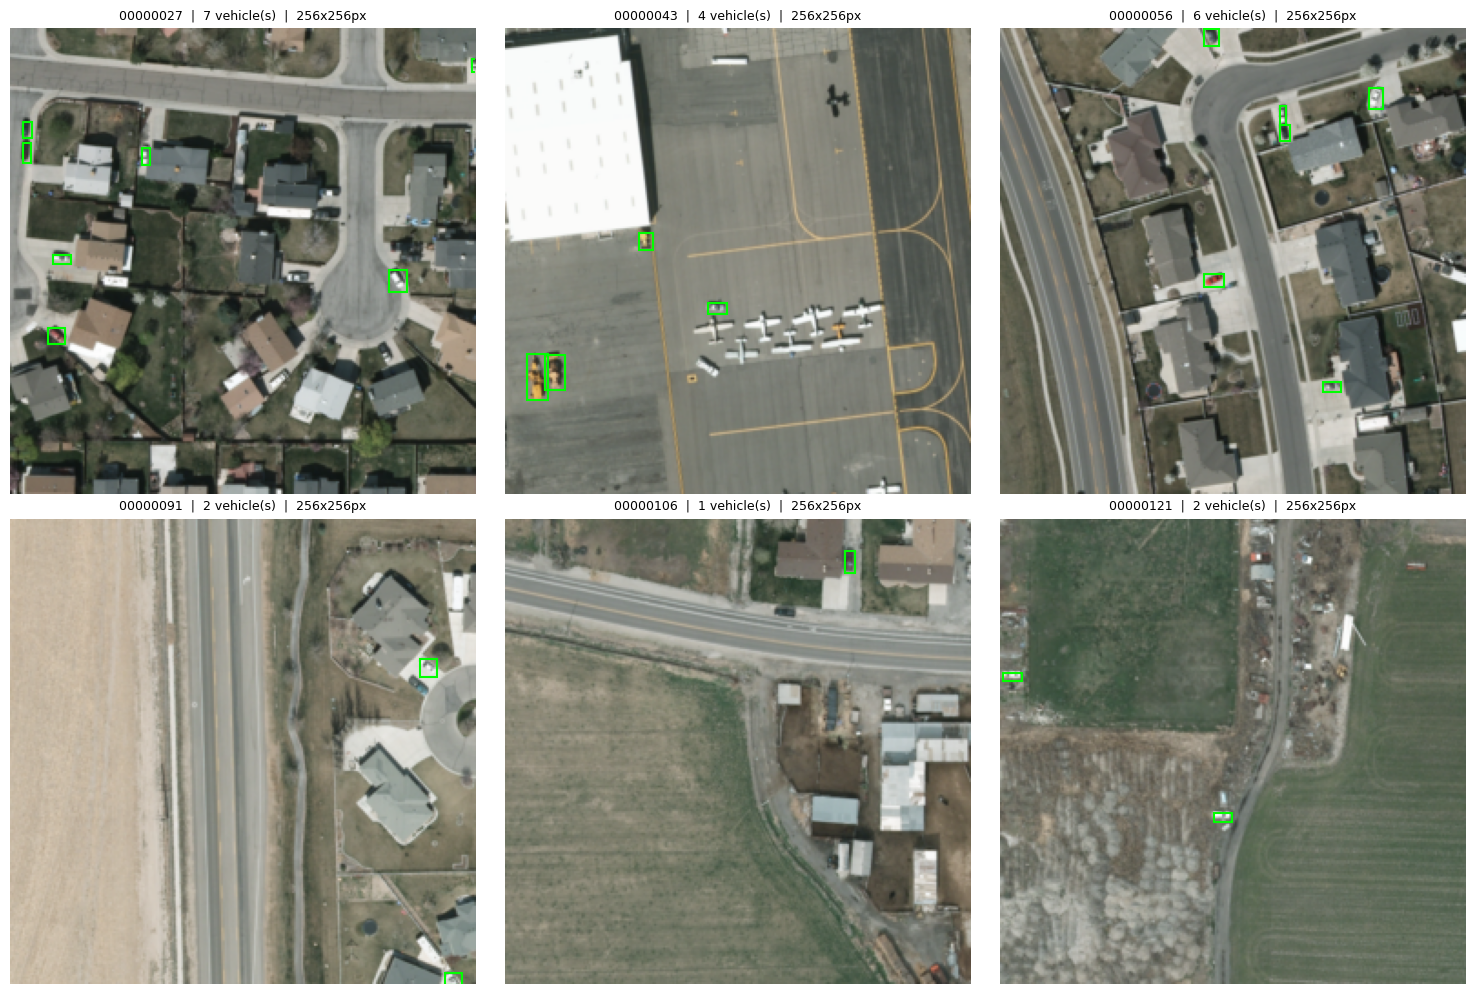

In [9]:
# Show the first images that actually contain vehicles (skip pure negatives),
# so you can judge box fit. Re-run with SPLIT="val" to check the val split.
with_boxes = [p for p in img_paths
              if load_label(PROC/"labels"/SPLIT/(p.stem+".txt"))]
sample = with_boxes[:6]

cols = 3
rows = (len(sample) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))
for ax, p in zip(np.array(axes).ravel(), sample):
    show_image_with_boxes(p, ax=ax)
for ax in np.array(axes).ravel()[len(sample):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

### Negatives 

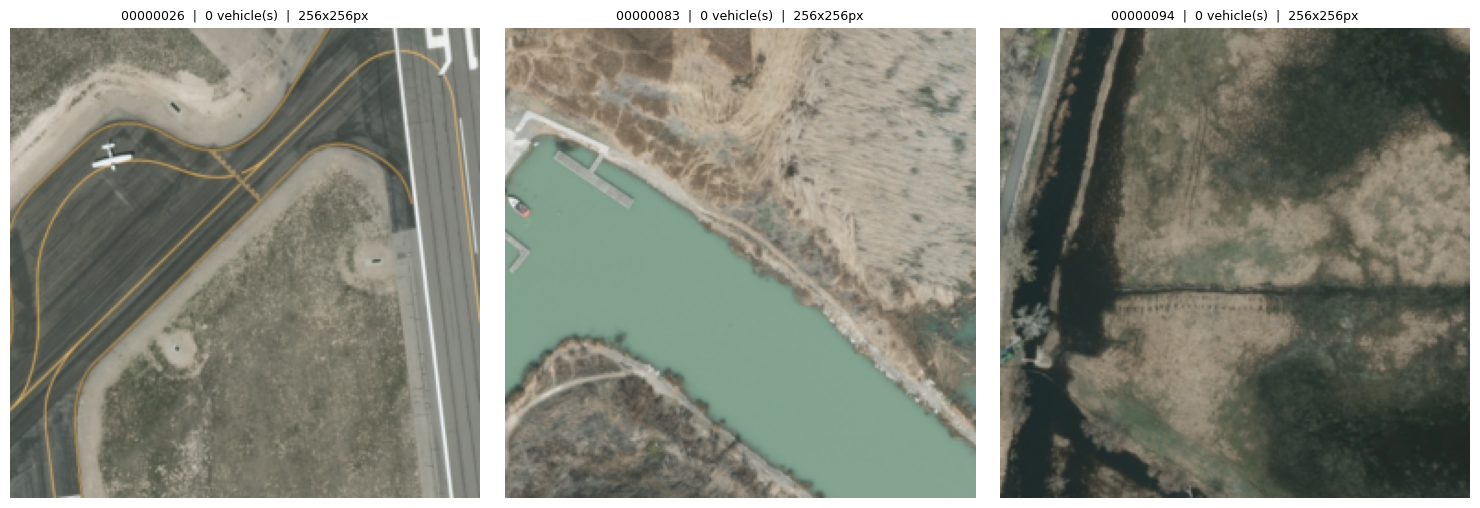

In [10]:
# Sanity-check a couple of NEGATIVES (images whose only objects were dropped
# classes — boat/plane/tractor/bus/'other'). They should show no green boxes;
# confirm there genuinely is no car you accidentally dropped.
negs = [p for p in img_paths
        if not load_label(PROC/"labels"/SPLIT/(p.stem+".txt"))][:3]
if negs:
    fig, axes = plt.subplots(1, len(negs), figsize=(len(negs)*5, 5))
    for ax, p in zip(np.atleast_1d(axes), negs):
        show_image_with_boxes(p, ax=ax)
    plt.tight_layout(); plt.show()
else:
    print("no negative images in this split")